# Applied Statistics Project

Thus far, throughout the course of the Applied Statistics Module, we have looked at -

- [Lady Tasting Tea Experiment](https://en.wikipedia.org/wiki/Lady_tasting_tea)

- [ANOVA (Analysis Of Variance)](https://en.wikipedia.org/wiki/Analysis_of_variance)

- [Normal Distribution](https://en.wikipedia.org/wiki/Normal_distribution)

- Permutations & Combinations

- [Binomial Distribution](https://numpy.org/doc/stable/reference/random/generated/numpy.random.binomial.html)

- Flipping Two & Many Coins

- Bell Curves

- [Histograms with Matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)

- [Sampling Distribution](https://en.wikipedia.org/wiki/Sampling_distribution)





In [2]:
# Library Imports (based on approved libraries in Assessment Guidelines)
import pandas as pd

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np
# Scipy Add-On to Numpy
import scipy

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# Seaborn - Alternative to Matplotlib
import seaborn as sns

# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math


## Problem 1: Extending The Lady Tasting Tea

### Instructions:

* The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

* Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

* Explain the simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.


### [math.comb(n, k)](https://docs.python.org/3/library/math.html#math.comb)

Calculate the number of ways to choose **k** elements from a set of **n** elements where the order of the chosen elements does not matter and no element is selected more than once.

In [3]:
# Expanding to 12 cups
cups = 12

# Cups with tea first
cups_teafirst = 8

# Cups with milk first
cups_milkfirst = 4


### Calculating Probability


$\binom{n}{k} = \frac{n!}{k!(n-k)!}$.



In [4]:
# Number of ways of selecting 8 cups from 12
ways_teafirst = math.comb(cups, cups_teafirst)

prob_teafirst = 1 / ways_teafirst
print(prob_teafirst)

0.00202020202020202


### Using Numpy to Calculate

The use of lecture materials is a starting point but simulating the experiment with random shuffling soon lead me down a research path towards [__The Monte Carlo Method__](https://en.wikipedia.org/wiki/Monte_Carlo_method).

> The Monte Carlo methods a broad class of computational algorithms that rely on repeated random sampling to obtain numerical results. - Wikipedia.

> Monte Carlo methods vary, but tend to follow a particular pattern: 

> Define a domain of possible inputs.

> Generate inputs randomly from a probability distribution over the domain.

> Perform a deterministic computation of the outputs.

> Aggregate the results.
-----

#### Applying The Pattern To Lady Tasting Tea

1. **Define a domain of possible inputs:**  
   - The domain consists of all possible permutations of the 12 cups (8 tea-first, 4 milk-first).

2. **Generate inputs randomly from a probability distribution over the domain:**  
   - Each trial shuffles the 12 cups randomly (`np.random.permutation(true_cups)`), simulating a random guess by the participant.

3. **Perform a deterministic computation of the outputs:**  
   - For each trial, check whether the shuffled sequence exactly matches the true sequence of cups (`np.array_equal(guess, true_cups)`).

4. **Aggregate the results:**  
   - After running many trials (in this case, N = 1,000,000), calculate the fraction of trials where the guess was perfectly correct. This empirical probability approximates the probability of a participant identifying all cups by chance.

------

#### Selecting An Appropriate _N_ Value
I found the MIT lecture titled 'Introduction To Computational Thinking And Data Science' helpful in my understanding of the importance of the _N_ value for running a Monte Carlo simulation. In particular, Professor Guttag highlights the relevance of [_The Law of Large Numbers_](https://en.wikipedia.org/wiki/Law_of_large_numbers) which states that as the number of independent trials increases, the sample mean (in this case, the simulated probability of a perfect guess) will converge to the true underlying probability.

In [5]:
# Setting A Seed For Reproducibility
# https://numpy.org/doc/stable/reference/random/legacy.html
np.random.seed(1)

# Simulate 1,000,000 times to see how close it gets to calculated probability
n_value = 1000000


In [6]:
# Simulation Function
def lady_tasting_tea_sim(cups_teafirst, cups_milkfirst, N=n_value):
    # Preparing counter of simulated correct selections
    correct_selections = 0

    # Sequence of Cups
    true_cups = ['T']*cups_teafirst + ['M']*cups_milkfirst
    
    # Loop Through The Code N number of times
    for _ in range(N):
        # Shuffle the cups to simulate a random guess
        # np.random.permutation returns a new array with elements randomly permuted. Reference: https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html
        guess = np.random.permutation(true_cups)

        # Check if the shuffled sequence matches the true sequence
        # np.array_equal checks whether two arrays have the same shape and elements. Reference: https://numpy.org/doc/stable/reference/generated/numpy.array_equal.html
        if np.array_equal(guess, true_cups):
            correct_selections += 1  # Increment counter if perfect guess  # Increment counter of simulated correct selections by 1
            
    # Return the fraction of perfect guesses
    return correct_selections / N

In [7]:
# Result of 12 Cup Simulation
prob_12_cups = lady_tasting_tea_sim(cups_teafirst=8, cups_milkfirst=4, N=n_value)
print("Simulated probability of perfect guess for 12 cups:", prob_12_cups)


Simulated probability of perfect guess for 12 cups: 0.002039


### The 12 Cup Result
In this experiment, each trial produces a binary outcome—either the participant’s random guess perfectly matches the correct 8 cups (success = 1) or it does not (0). The Monte Carlo estimate is the sample mean of many Bernoulli trials, exactly the type of situation where the Law of Large Numbers applies.

$\hat{p} = \frac{\text{correct\_selections}}{N}$.

Because the true probability of a perfect guess in the 12-cup design is very small, a large _N_ leverages the Law of Large Numbers to make the Monte Carlo estimate more reliable, especially when modelling a perfect identification of the 8 cups of tea where tea is poured first by chance.

$\frac{1}{\binom{12}{8}} = 0.0020202\ldots$


In my simulation (with _N_= 1,000,000), the estimated probability was:

$\hat{p}_{\text{sim}} = 0.002039$

which is extremely close to the theoretical probability. This closeness provides strong evidence that the Monte Carlo process is functioning correctly and that a participant identifying all 8 tea-first cups by chance in a 12-cup test is even less likely than in the original 8-cup design.

### Comparing The 8 Cup and 12 Cup Results

In [8]:
# Probability of 4 correct cups selected from 8 
# The probability that she (randomly) selects the four correct cups.
original_prob = 1 / 70
original_prob

0.014285714285714285

In [9]:
# Using The Simulation Function To Simulate The Original 8 Cup Experiment
prob_8_cups = lady_tasting_tea_sim(cups_teafirst=4, cups_milkfirst=4, N=n_value)
print("Simulated probability of perfect guess for 8 cups:", prob_8_cups)

Simulated probability of perfect guess for 8 cups: 0.014334


#### Comparing
The original 8 cup expirement had a probability of 1.4% for identifying the correct 4 cups where milk was poured first. This approximate probability was seen in the calculated and simulated test. 

The increased difficulty of correctly identifying the 8 cups out of 12 that tea was poured first is proven in the significantly reduced probability of 0.02%. The decrease is expected because the sequence to match is longer and the number of permutations increases factorially. 

##### Link to Fisher’s Exact Test
The Lady Tasting Tea experiment is historically significant, as it motivated the development of what is now called [Fisher's Exact Test](https://en.wikipedia.org/wiki/Fisher%27s_exact_test). 

Fisher designed the original experiment as an example of exact inference, in which:

> “the significance of the deviation from a null hypothesis can be calculated exactly, rather than relying on an approximation.” — Wikipedia: Fisher’s Exact Test

Fisher’s reasoning was that when the margins of a contingency table are fixed, the exact probability of the observed arrangement under the null can be computed without approximation.

Although the extended 12-cup experiment does not match the form of a 2×2 contingency table, the same principle of exact inference applies here: under the null hypothesis, every permutation of cup labels is equally likely. The Monte Carlo simulation approximates this exact probability by repeatedly randomising the sequence of labels.

##### **Extending/Relaxing The _p_ Value**
![_p_ Value](https://imgs.xkcd.com/comics/p_values.png)

__Credit:__ [xkcd](https://xkcd.com/1478)

The xkcd cartoon “P-Values” satirises the common practice of treating p < 0.05 as an absolute cut-off for declaring “significance.”

The interpretation of p-values depends on comparing them to a chosen significance level $\alpha$. Common practice uses $\alpha$ = 0.05, but other thresholds such as 0.10 (“weak evidence”) or 0.001 (“very strong evidence”) also appear in statistical guidelines. According to a practical overview from GeeksforGeeks, smaller p-values correspond to stronger evidence against the null hypothesis, while larger p-values indicate weaker evidence and a failure to rule out chance as an explanation [(GeeksforGeeks, Understanding the p-value)](https://www.geeksforgeeks.org/machine-learning/p-value/).

In the context of this extended Lady-Tasting-Tea simulation, the estimated probability of correctly identifying the 8 cups where tea was poured first by chance is around 0.002. Using conventional interpretations, this would fall into the category of “highly significant” evidence against the null. Such a small probability could justify using a stricter significance threshold (e.g., $\alpha$ = 0.01) rather than the traditional 0.05, since the experiment naturally produces extremely low p-values under random guessing.



## Problem 2: Normal Distribution

### Instructions:

* Generate 100,000 samples of size 10 from the standard normal distribution. 
* For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). 
* Plot histograms of both sets of values on the same axes with transparency. 
* Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

------


In [10]:
# Using Numpy TO Generate Samples
# See: https://numpy.org/doc/stable/reference/random/generator.html
# See: https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

# Parameters
num_samples = 100000
sample_size = 10
rng = np.random.default_rng(1) # Using same seed from Problem 1
data = rng.standard_normal(size=(num_samples, sample_size))




In [12]:
# Calculate Mean (Similar to normal-distribution Jupyter Notebook from lectures)
means = np.mean(data, axis=1)

means

array([ 0.22490824, -0.14993373, -0.27328459, ...,  0.03283486,
       -0.48508471, -0.0375708 ], shape=(100000,))

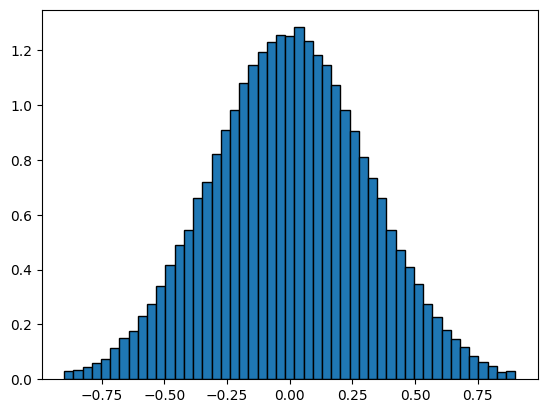

In [15]:
# Create a blank plot.
fig, ax = plt.subplots()

# Create a histogram.
ax.hist(means, edgecolor='black', density=True, bins=np.linspace(-0.9, 0.9, 50));

#### Computing Standard Deviation
----------

## Problem 3: t-Tests

### Instructions:

* A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference *d* = 0,0.1,0.2,…,1.0 , repeat the following simulation 1,000 times:

    1. Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean *d* and standard deviation 1.
    2. Run an independent samples t-test on the two samples, rejecting the null hypothesis if the *p-value* is less than 0.05.
    3. Record the proportion of times the null hypothesis is not rejected.

* Plot this proportion against *d*, and explain how the type II error rate changes as the difference in means increases.

## Problem 4: t-Anova

### Instructions:

* Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

    1. Perform a one-way ANOVA to test whether all three means are equal.
    2. Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.
    3. Compare the conclusions.

* Write a short note on why ANOVA is preferred over running several t-tests.